## Stage 1 — Setup

In [21]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from skfda import FDataGrid
from skfda.preprocessing.smoothing import BasisSmoother
from skfda.representation.basis import BSplineBasis
from skfda.preprocessing.dim_reduction import FPCA
from skfda.preprocessing.registration import FisherRaoElasticRegistration

sys.path.insert(0, str(Path('..') / 'src'))
from classify_loader import load_manifest, load_edf

plt.style.use('../imagestyle.mplstyle')

ROOT    = Path('..')
CSV     = ROOT / 'Kural_Dataset' / 'eeg_summary.csv'
EDF_DIR = ROOT / 'Kural_Dataset' / 'Recordings'

## Stage 2 — Load CSV + build narrow dataset

Fixed ±1 s window (1000 samples at 500 Hz) centred on `transient_onset_s`. Same channel-selection logic as the wide arm (most-active by peak-to-peak in ±0.1 s).

In [2]:
manifest = load_manifest(CSV)
print(f"Usable recordings: {len(manifest)}")
print(f"pre_transient_s  min: {manifest['pre_transient_s'].min():.3f} s  ->  1.0 s window fits")
print(f"post_transient_s min: {manifest['post_transient_s'].min():.3f} s  ->  1.0 s window fits")

SFREQ     = 500.0
HALF_S    = 1.0
HALF_N    = int(HALF_S * SFREQ)          # 500
PEAK_HALF = int(round(0.1 * SFREQ))      # ±0.1 s for channel selection

curves, labels, certs = [], [], []
for _, row in manifest.iterrows():
    raw   = load_edf(row['file_id'], EDF_DIR)
    onset = int(round(row['transient_onset_s'] * SFREQ))
    data  = raw.get_data(start=onset - HALF_N, stop=onset + HALF_N)
    ch    = np.argmax(np.ptp(data[:, HALF_N - PEAK_HALF: HALF_N + PEAK_HALF], axis=1))
    curves.append(data[ch])
    labels.append(row['label_binary'])
    certs.append(row['certainty'])

t    = (np.arange(2 * HALF_N) - HALF_N) / SFREQ
fd   = FDataGrid(data_matrix=np.stack(curves), grid_points=t)
y    = np.array(labels)
cert = np.array(certs)

assert fd.data_matrix.shape == (100, 1000, 1), f"Shape mismatch: {fd.data_matrix.shape}"
print(f"FDataGrid shape: {fd.data_matrix.shape}  (100 curves x 1000 samples)")
for g, c in zip(*np.unique(cert, return_counts=True)):
    print(f"  {g}: {c}")

Usable recordings: 100
pre_transient_s  min: 2.330 s  ->  1.0 s window fits
post_transient_s min: 5.083 s  ->  1.0 s window fits
FDataGrid shape: (100, 1000, 1)  (100 curves x 1000 samples)
  clear_positive: 22
  negative: 46
  unclear_positive: 32


## Stage 3 — Inspect + diagnose annotation

Overlay all 100 narrow windows to determine marker meaning: peak, onset, or something else?

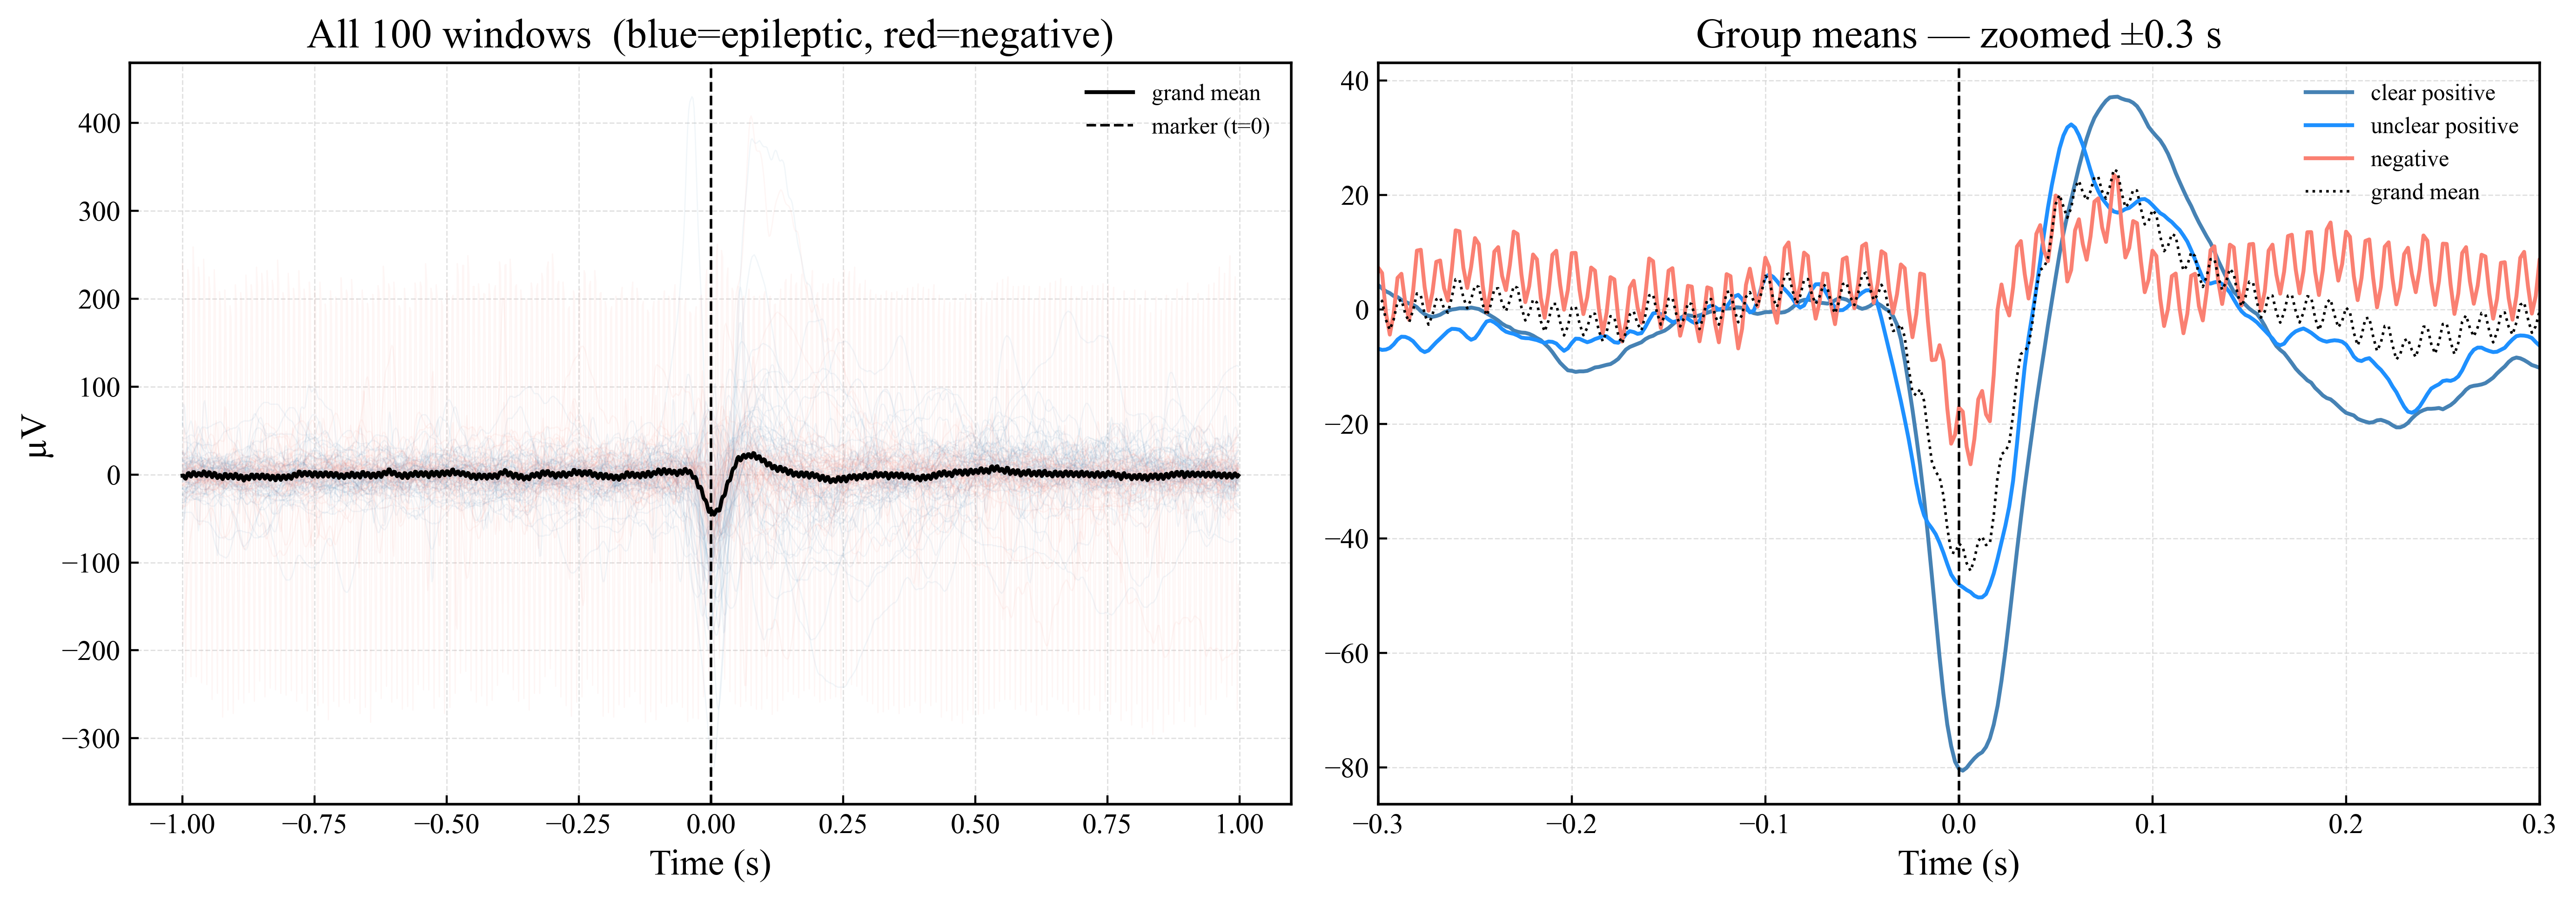

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i in range(len(fd)):
    col = 'steelblue' if y[i] == 1 else 'salmon'
    axes[0].plot(t, fd.data_matrix[i,:,0]*1e6, color=col, alpha=0.07, lw=0.5)
mean_all = fd.data_matrix[:,:,0].mean(axis=0)
axes[0].plot(t, mean_all*1e6, 'k', lw=1.5, label='grand mean')
axes[0].axvline(0, color='k', ls='--', lw=1, label='marker (t=0)')
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('µV')
axes[0].set_title('All 100 windows  (blue=epileptic, red=negative)')
axes[0].legend(fontsize=9)

for g, col in [('clear_positive','steelblue'),('unclear_positive','dodgerblue'),('negative','salmon')]:
    m = fd.data_matrix[cert==g,:,0].mean(axis=0)
    axes[1].plot(t, m*1e6, lw=1.5, label=g.replace('_',' '), color=col)
axes[1].plot(t, mean_all*1e6, 'k', lw=1, ls=':', label='grand mean')
axes[1].axvline(0, color='k', ls='--', lw=1)
axes[1].set_xlim(-0.3, 0.3)
axes[1].set_xlabel('Time (s)'); axes[1].set_title('Group means — zoomed ±0.3 s')
axes[1].legend(fontsize=9)

plt.tight_layout(); plt.show()

## Stage 4 — Smoothing (exploratory)

B-spline basis projection. Fisher-Rao's SRSF step amplifies noise, so smooth first.

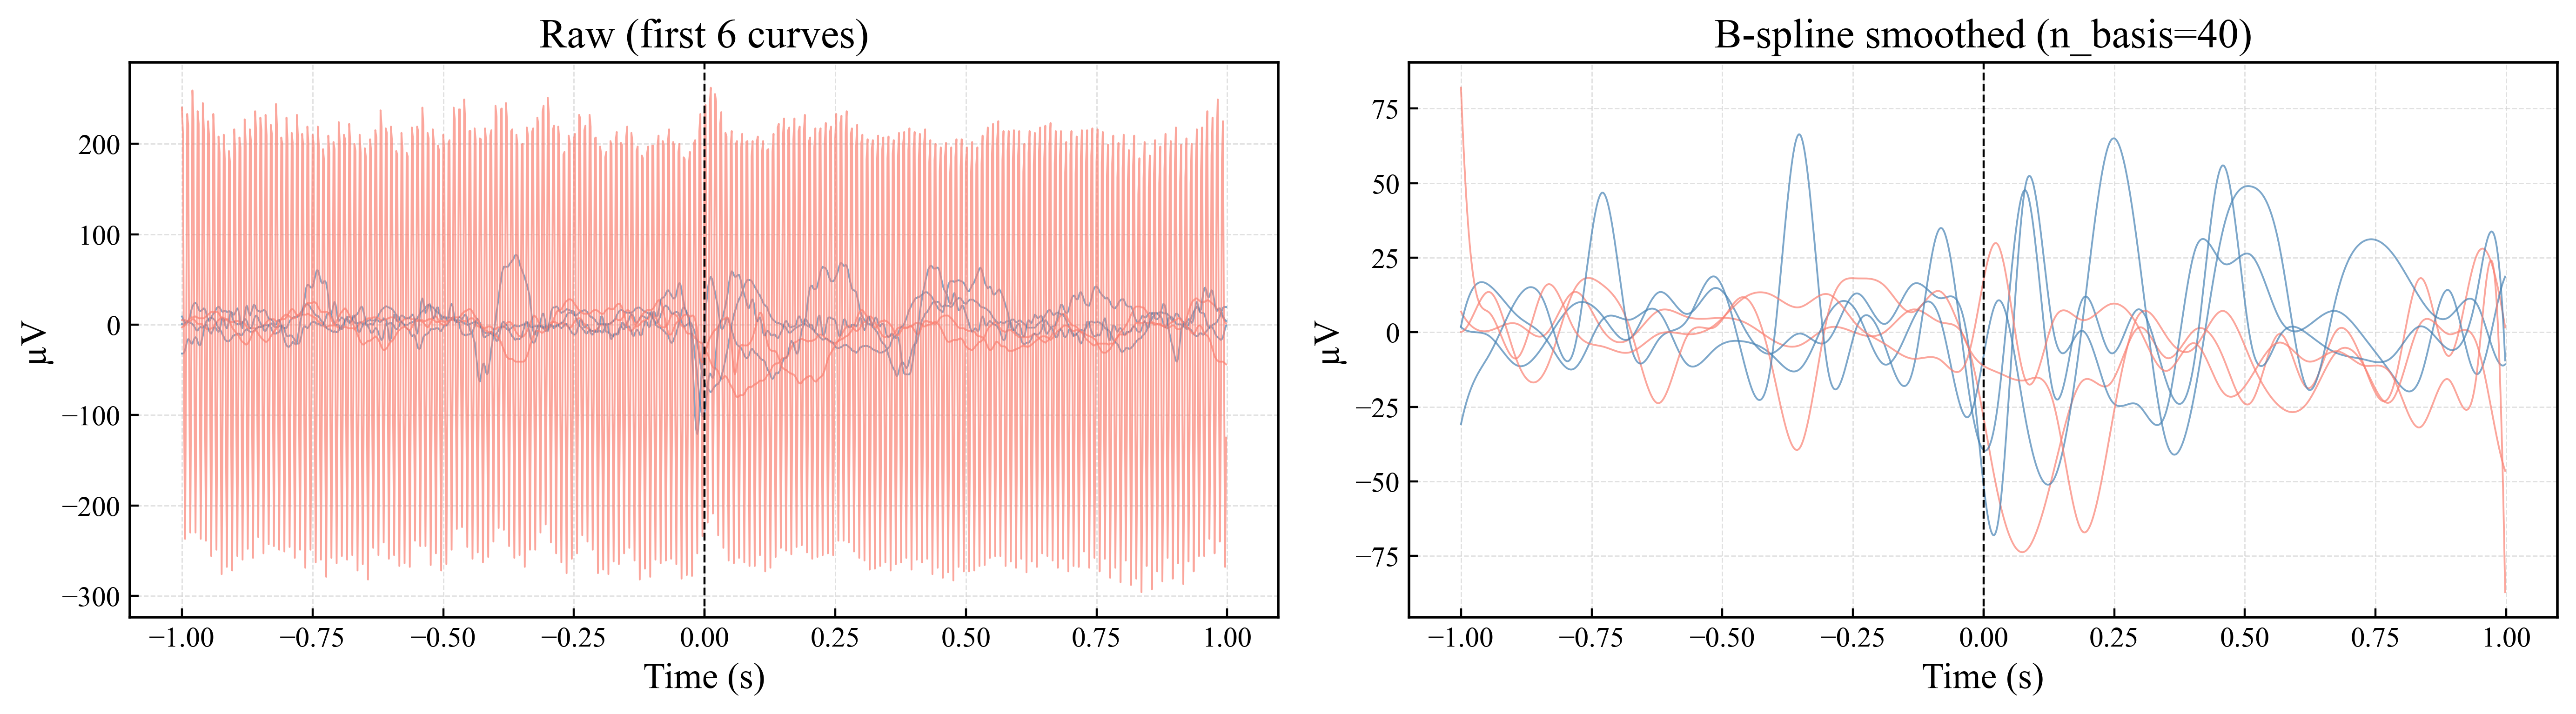

In [4]:
domain   = (t[0], t[-1])
N_BASIS  = 40

smoother_ex  = BasisSmoother(BSplineBasis(domain_range=domain, n_basis=N_BASIS, order=4), return_basis=False)
fd_smooth_ex = smoother_ex.fit_transform(fd)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for i in range(6):
    col = 'steelblue' if y[i]==1 else 'salmon'
    axes[0].plot(t, fd.data_matrix[i,:,0]*1e6,         color=col, alpha=0.7, lw=0.7)
    axes[1].plot(t, fd_smooth_ex.data_matrix[i,:,0]*1e6, color=col, alpha=0.7, lw=0.7)
for ax in axes:
    ax.axvline(0, color='k', ls='--', lw=0.8)
    ax.set_xlabel('Time (s)'); ax.set_ylabel('µV')
axes[0].set_title('Raw (first 6 curves)')
axes[1].set_title(f'B-spline smoothed (n_basis={N_BASIS})')
plt.tight_layout(); plt.show()

## Stage 5 — Registration leakage check

Fit registration on training set, transform test set, confirm `template_` object identity is unchanged. This proves `transform()` reuses the fitted template rather than re-estimating from new data.

In [5]:
fd_all_smooth = smoother_ex.fit_transform(fd)

# Resample to 100 pts before registration (DP warp is O(n^2); 1000->100 pts is ~100x faster)
N_REG = 100
t_reg = np.linspace(t[0], t[-1], N_REG)
fd_sm_coarse = FDataGrid(fd_all_smooth(t_reg).squeeze(-1), t_reg)

train_smooth = fd_sm_coarse[:80]
test_smooth  = fd_sm_coarse[80:]

reg_check = FisherRaoElasticRegistration(penalty=0.1)
reg_check.fit(train_smooth)
tid_before = id(reg_check.template_)
_          = reg_check.transform(test_smooth)
tid_after  = id(reg_check.template_)

passed = tid_before == tid_after
print(f"template_ id before transform: {tid_before}")
print(f"template_ id after  transform: {tid_after}")
print()
print(f"Registration leakage check: {'PASSED -- template_ unchanged' if passed else 'FAILED'}")

template_ id before transform: 5614839168
template_ id after  transform: 5614839168

Registration leakage check: PASSED -- template_ unchanged


## Stage 6 — Registration demo (exploratory)

> **Exploratory only** — fits on all 100 for visualisation. The pipeline (Stage 7+) refits registration inside each fold on training data only.

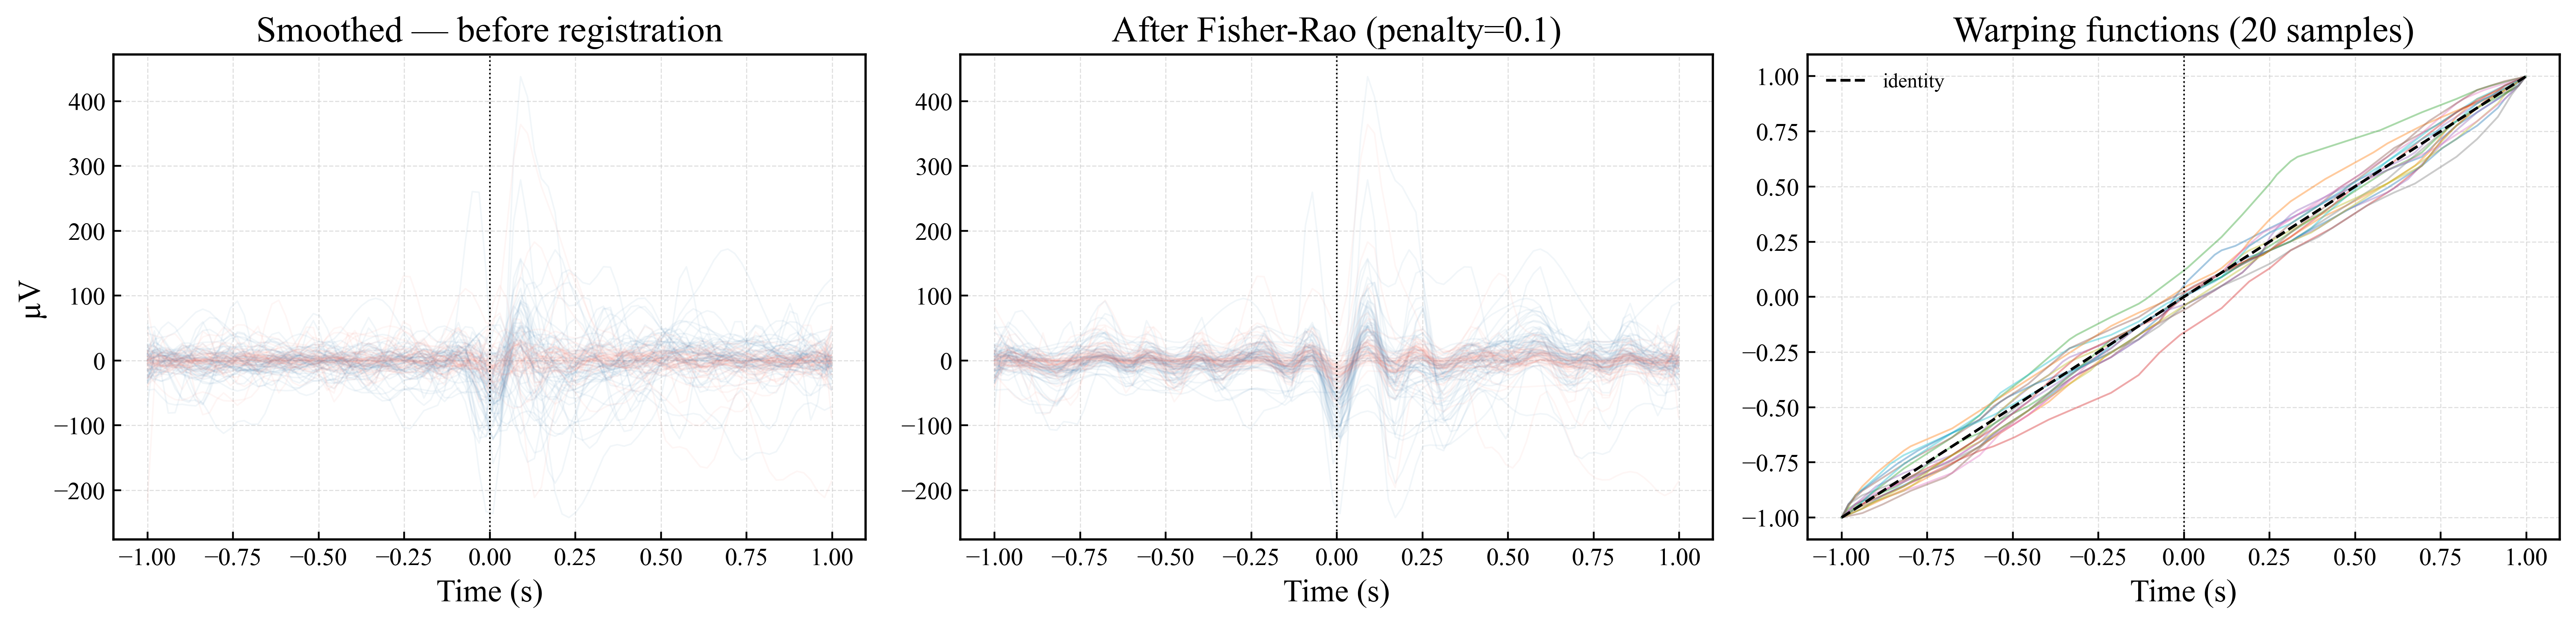

Warp magnitude (max |warp - identity|): mean=0.1179 s, max=0.3027 s


In [6]:
PENALTY  = 0.1
reg_demo = FisherRaoElasticRegistration(penalty=PENALTY)
fd_aligned_demo = reg_demo.fit_transform(fd_sm_coarse)
warps_demo = reg_demo.warping_.data_matrix[:, :, 0]
t_r = t_reg  # short alias for plot axis

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i in range(len(fd_sm_coarse)):
    col = 'steelblue' if y[i]==1 else 'salmon'
    axes[0].plot(t_r, fd_sm_coarse.data_matrix[i,:,0]*1e6, color=col, alpha=0.07, lw=0.7)
axes[0].set_title('Smoothed — before registration'); axes[0].set_ylabel('µV')

for i in range(len(fd_aligned_demo)):
    col = 'steelblue' if y[i]==1 else 'salmon'
    axes[1].plot(t_r, fd_aligned_demo.data_matrix[i,:,0]*1e6, color=col, alpha=0.07, lw=0.7)
axes[1].set_title(f'After Fisher-Rao (penalty={PENALTY})')

for i in range(20):
    axes[2].plot(t_r, warps_demo[i], alpha=0.4, lw=0.8)
axes[2].plot(t_r, t_r, 'k--', lw=1.2, label='identity')
axes[2].set_title('Warping functions (20 samples)'); axes[2].legend(fontsize=9)

for ax in axes:
    ax.set_xlabel('Time (s)')
    ax.axvline(0, color='k', ls=':', lw=0.7)
plt.tight_layout(); plt.show()

warp_dev = np.abs(warps_demo - t_r[None,:]).max(axis=1)
print(f"Warp magnitude (max |warp - identity|): mean={warp_dev.mean():.4f} s, max={warp_dev.max():.4f} s")

## Stage 7 — Build the three pipelines

`RegistrationFeatureTransformer` encapsulates smooth → register → FPCA, leakage-safe as a sklearn step. Three instances differ only by `mode`. `class_weight='balanced'` prevents the majority-class collapse seen in the wide-window arm.

In [7]:
class RegistrationFeatureTransformer(BaseEstimator, TransformerMixin):
    '''Smooth -> resample to n_reg_points -> Fisher-Rao register -> FPCA on amplitude, phase, or both.
    
    Resampling to a coarse grid before registration is lossless after B-spline smoothing
    (40 basis functions have at most 40 dof) and cuts DP warp computation from O(1000^2) to O(100^2).
    '''

    def __init__(self, n_basis=40, penalty=0.1, n_components=5, mode='amplitude', n_reg_points=100):
        self.n_basis      = n_basis
        self.penalty      = penalty
        self.n_components = n_components
        self.mode         = mode
        self.n_reg_points = n_reg_points

    def fit(self, X, y=None):
        domain = X.domain_range[0]
        self._smoother = BasisSmoother(
            BSplineBasis(domain_range=domain, n_basis=self.n_basis, order=4),
            return_basis=False
        )
        X_smooth = self._smoother.fit_transform(X)
        self._t_reg = np.linspace(domain[0], domain[1], self.n_reg_points)
        X_coarse  = FDataGrid(X_smooth(self._t_reg).squeeze(-1), self._t_reg)
        self._reg = FisherRaoElasticRegistration(penalty=self.penalty)
        X_aligned = self._reg.fit_transform(X_coarse)
        if self.mode in ('amplitude', 'both'):
            self._fpca_amp = FPCA(n_components=self.n_components)
            self._fpca_amp.fit(X_aligned)
        if self.mode in ('phase', 'both'):
            self._fpca_phase = FPCA(n_components=self.n_components)
            self._fpca_phase.fit(self._reg.warping_)
        return self

    def transform(self, X):
        X_smooth  = self._smoother.transform(X)
        X_coarse  = FDataGrid(X_smooth(self._t_reg).squeeze(-1), self._t_reg)
        X_aligned = self._reg.transform(X_coarse)
        feats = []
        if self.mode in ('amplitude', 'both'):
            feats.append(self._fpca_amp.transform(X_aligned))
        if self.mode in ('phase', 'both'):
            feats.append(self._fpca_phase.transform(self._reg.warping_))
        return np.hstack(feats) if len(feats) > 1 else feats[0]


def make_pipe(mode):
    return Pipeline([
        ('features', RegistrationFeatureTransformer(n_basis=40, penalty=0.1, n_components=5,
                                                    mode=mode, n_reg_points=100)),
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=1000, class_weight='balanced'))
    ])

amp_pipe   = make_pipe('amplitude')
phase_pipe = make_pipe('phase')
both_pipe  = make_pipe('both')

scalar_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

print("Pipelines ready: amplitude | phase | both | scalar (peak-to-peak baseline)")
print("Registration runs on 100-pt resampled curves (from 40-basis B-spline: lossless, ~100x faster)")

Pipelines ready: amplitude | phase | both | scalar (peak-to-peak baseline)
Registration runs on 100-pt resampled curves (from 40-basis B-spline: lossless, ~100x faster)


## Stage 8 — CV setup

Manual repeated stratified K-fold: stratify on 3-way `certainty`, train on binary `y`. 20 repeats × 5 folds.

In [8]:
N_REPEATS = 20
N_FOLDS   = 5
n         = len(y)

X_scalar = np.ptp(
    fd.data_matrix[:, HALF_N - PEAK_HALF: HALF_N + PEAK_HALF, 0],
    axis=1, keepdims=True
) * 1e6
print(f"Scalar feature (peak-to-peak ±0.1 s): [{X_scalar.min():.1f}, {X_scalar.max():.1f}] uV")

def compute_metrics(y_true, y_prob, cert):
    auc      = roc_auc_score(y_true, y_prob)
    y_pred   = (y_prob >= 0.5).astype(int)
    neg_mask = cert == 'negative'
    clr_mask = cert == 'clear_positive'
    unc_mask = cert == 'unclear_positive'
    spec     = np.mean(y_pred[neg_mask] == 0) if neg_mask.any() else np.nan
    sens_clr = np.mean(y_pred[clr_mask] == 1) if clr_mask.any() else np.nan
    sens_unc = np.mean(y_pred[unc_mask] == 1) if unc_mask.any() else np.nan
    return {'auc': auc, 'specificity': spec, 'sens_clear': sens_clr, 'sens_unclear': sens_unc}

print(f"CV: {N_REPEATS} repeats x {N_FOLDS}-fold, stratified on cert, train on y")

Scalar feature (peak-to-peak ±0.1 s): [47.0, 649.0] uV
CV: 20 repeats x 5-fold, stratified on cert, train on y


## Stage 9 — Reference baselines

Majority class and scalar peak-to-peak LR — same as the wide-window arm. Wide-window scalar LR AUC was 0.719; that is the number to beat.

In [9]:
print("Baselines (computed inside CV loop to avoid leakage):")
print("  majority class  -- OOF probability = training positive rate per fold")
print("  scalar LR       -- peak-to-peak amplitude in +-0.1 s, balanced LR")
print()
print("Wide-window scalar LR AUC = 0.719  <-- threshold: registration must beat this to add value")

Baselines (computed inside CV loop to avoid leakage):
  majority class  -- OOF probability = training positive rate per fold
  scalar LR       -- peak-to-peak amplitude in +-0.1 s, balanced LR

Wide-window scalar LR AUC = 0.719  <-- threshold: registration must beat this to add value


## Stage 10 — Run evaluation

20 repeats × 5 folds. Pooled OOF probabilities per repeat → one metric value per repeat. All five conditions evaluated in the same loop.

In [10]:
repeat_results = []
avg_probs = {m: np.zeros(n) for m in ['amplitude','phase','both','majority','scalar']}
MODELS = [('amplitude',amp_pipe), ('phase',phase_pipe), ('both',both_pipe)]

for repeat in range(N_REPEATS):
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=repeat)
    oof = {m: np.zeros(n) for m in avg_probs}

    for train_idx, test_idx in skf.split(np.arange(n), cert):
        fd_tr, fd_te = fd[train_idx], fd[test_idx]
        X_tr,  X_te  = X_scalar[train_idx], X_scalar[test_idx]
        y_tr         = y[train_idx]

        for name, pipe in MODELS:
            pipe.fit(fd_tr, y_tr)
            oof[name][test_idx] = pipe.predict_proba(fd_te)[:, 1]

        oof['majority'][test_idx] = np.mean(y_tr)
        scalar_pipe.fit(X_tr, y_tr)
        oof['scalar'][test_idx] = scalar_pipe.predict_proba(X_te)[:, 1]

    repeat_results.append({m: compute_metrics(y, oof[m], cert) for m in oof})
    for m in avg_probs:
        avg_probs[m] += oof[m]

    if (repeat + 1) % 5 == 0:
        print(f"  repeat {repeat+1:2d}/{N_REPEATS} done")

for m in avg_probs:
    avg_probs[m] /= N_REPEATS

print("Evaluation complete.")

  repeat  5/20 done
  repeat 10/20 done
  repeat 15/20 done
  repeat 20/20 done
Evaluation complete.


## Stage 11 — Results

AUC is the headline metric. Unclear-positive sensitivity is the headline clinical number. All values: mean (p10–p90) across 20 repeats.

In [11]:
metrics    = ['auc','specificity','sens_clear','sens_unclear']
met_labels = ['AUC','Specificity (neg)','Sens clear+','Sens unclear+']
conditions  = ['amplitude','phase','both','majority','scalar']
cond_labels = ['FDA amplitude','FDA phase','FDA both','Majority class','Scalar LR (ptp)']

rows = []
for cond, clabel in zip(conditions, cond_labels):
    row = {'Condition': clabel}
    for m, ml in zip(metrics, met_labels):
        vals = [r[cond][m] for r in repeat_results]
        mn,p10,p90 = np.mean(vals), np.percentile(vals,10), np.percentile(vals,90)
        row[ml] = f"{mn:.3f}  ({p10:.3f}-{p90:.3f})"
    rows.append(row)

results_df = pd.DataFrame(rows).set_index('Condition')
print(results_df.to_string())
print()
best_cond   = max(['amplitude','phase','both'], key=lambda m: np.mean([r[m]['auc'] for r in repeat_results]))
best_auc    = np.mean([r[best_cond]['auc']  for r in repeat_results])
scalar_auc  = np.mean([r['scalar']['auc']   for r in repeat_results])
print(f"Best FDA condition: {best_cond}  AUC {best_auc:.3f}")
print(f"Scalar LR baseline: AUC {scalar_auc:.3f}")
print(f"Delta (FDA - scalar): {best_auc - scalar_auc:+.3f}")

                                  AUC     Specificity (neg)           Sens clear+         Sens unclear+
Condition                                                                                              
FDA amplitude    0.874  (0.854-0.895)  0.860  (0.826-0.891)  0.807  (0.727-0.864)  0.706  (0.656-0.750)
FDA phase        0.560  (0.510-0.606)  0.533  (0.476-0.591)  0.509  (0.450-0.550)  0.559  (0.497-0.628)
FDA both         0.857  (0.836-0.889)  0.846  (0.800-0.891)  0.789  (0.682-0.823)  0.706  (0.656-0.753)
Majority class   0.484  (0.484-0.484)  0.000  (0.000-0.000)  1.000  (1.000-1.000)  1.000  (1.000-1.000)
Scalar LR (ptp)  0.741  (0.727-0.755)  0.787  (0.761-0.807)  0.625  (0.591-0.682)  0.520  (0.500-0.534)

Best FDA condition: amplitude  AUC 0.874
Scalar LR baseline: AUC 0.741
Delta (FDA - scalar): +0.133


## Stage 12 — Probability distribution by certainty

Averaged OOF probabilities across 20 repeats, split by certainty group, for the best FDA condition.

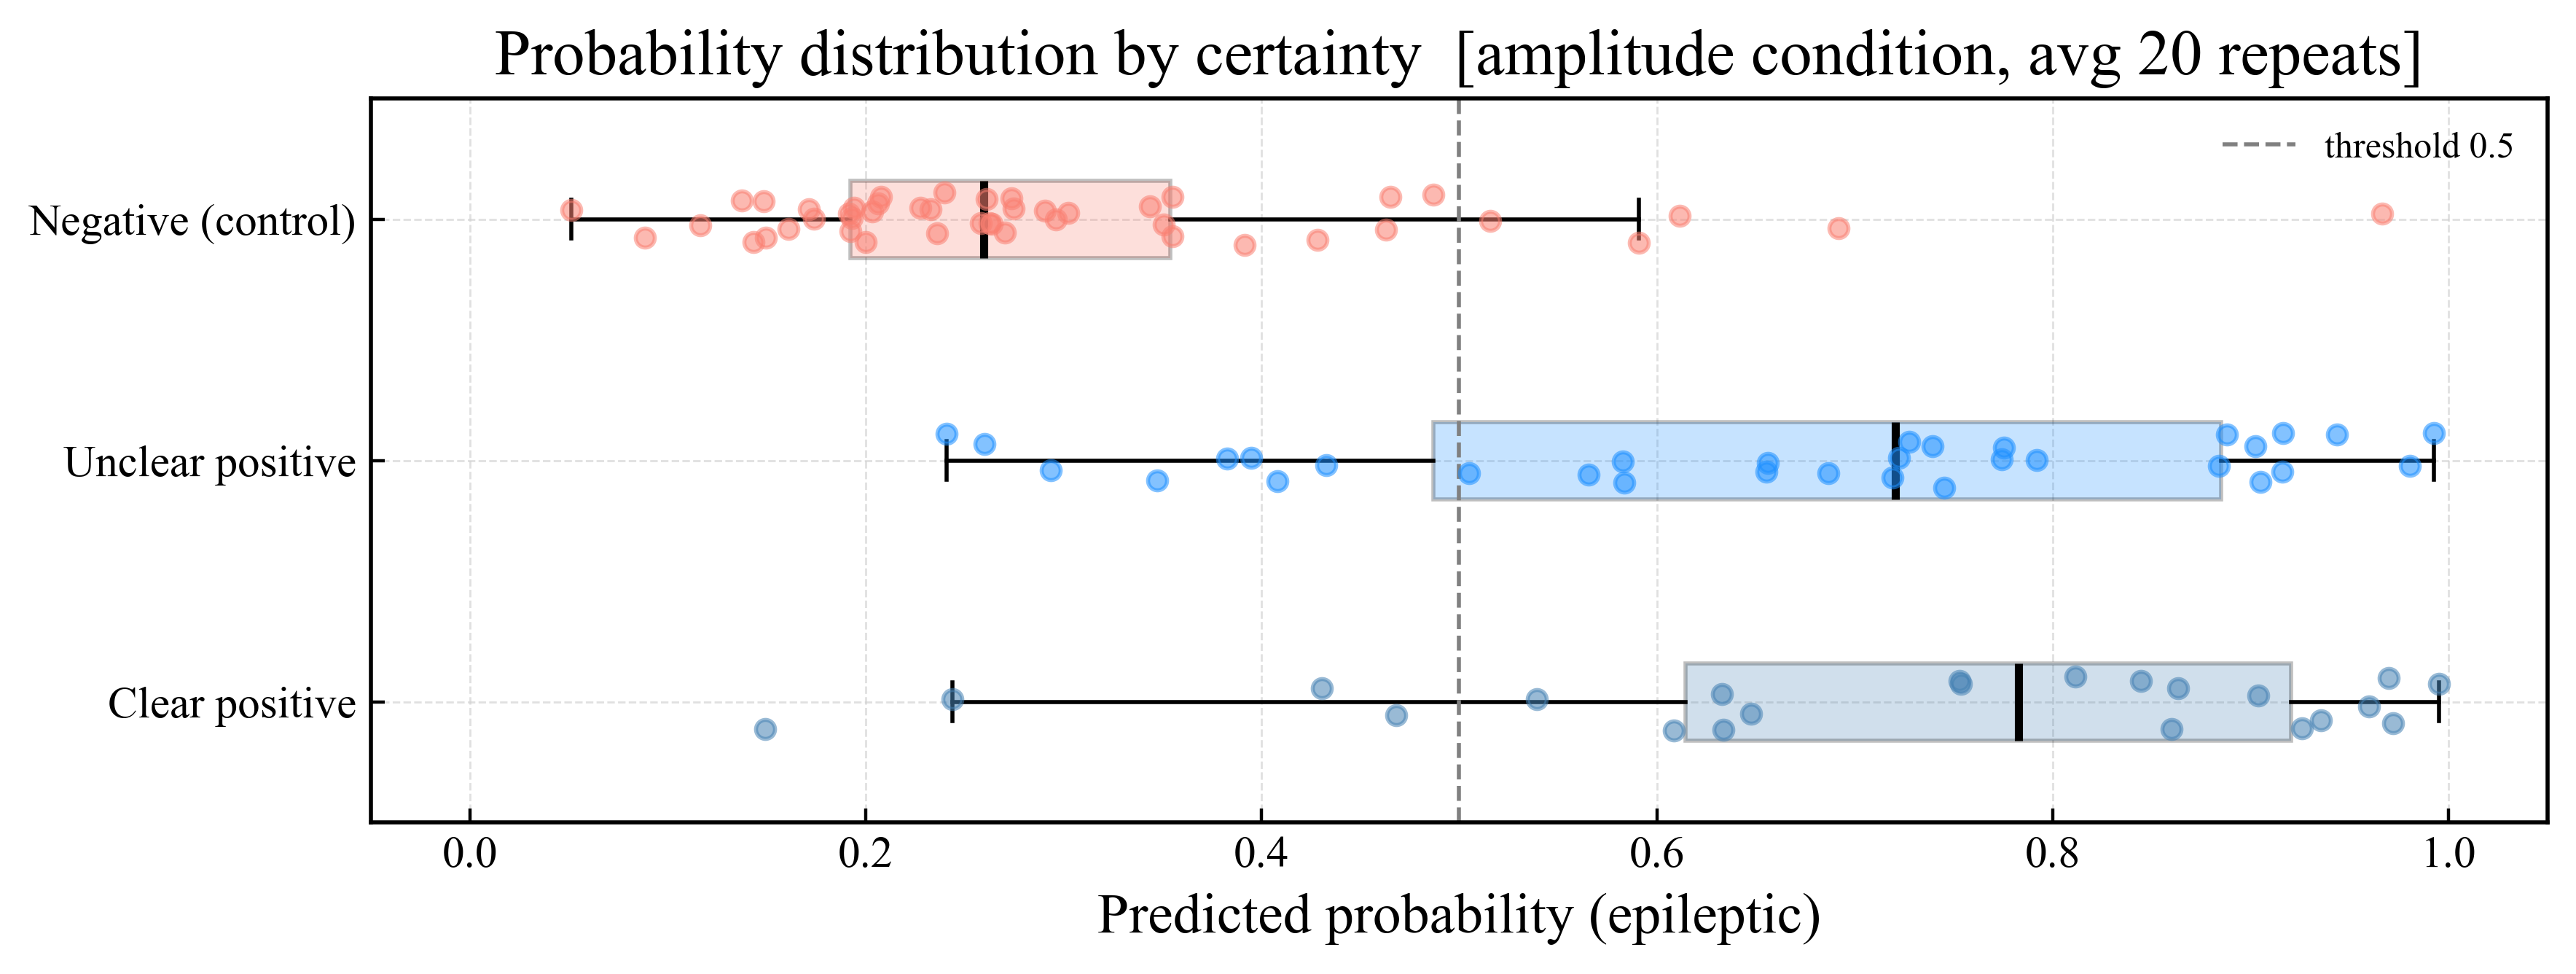

In [19]:
probs  = avg_probs[best_cond]
groups = ['clear_positive','unclear_positive','negative']
glbls  = ['Clear positive','Unclear positive','Negative (control)']
cols   = ['steelblue','dodgerblue','salmon']

fig, ax = plt.subplots(figsize=(9, 3.5))
for i, (g, gl, col) in enumerate(zip(groups, glbls, cols)):
    gp = probs[cert == g]
    jitter = np.random.default_rng(i).uniform(-0.12, 0.12, len(gp))
    ax.scatter(gp, np.full(len(gp), i) + jitter, alpha=0.55, s=22, color=col, zorder=3)
    ax.boxplot(gp, positions=[i], vert=False, widths=0.32,
               flierprops=dict(marker=''),
               medianprops=dict(color='k', lw=2),
               patch_artist=True,
               boxprops=dict(facecolor=col, alpha=0.25))
ax.set_yticks(range(len(groups)))
ax.set_yticklabels(glbls)
ax.set_xlabel('Predicted probability (epileptic)')
ax.axvline(0.5, color='gray', ls='--', lw=1, label='threshold 0.5')
ax.set_title(f'Probability distribution by certainty  [{best_cond} condition, avg {N_REPEATS} repeats]')
ax.legend(fontsize=9)
ax.set_xlim(-0.05, 1.05)
plt.tight_layout()
plt.show()

## Stage 13 — Confusion Matrices

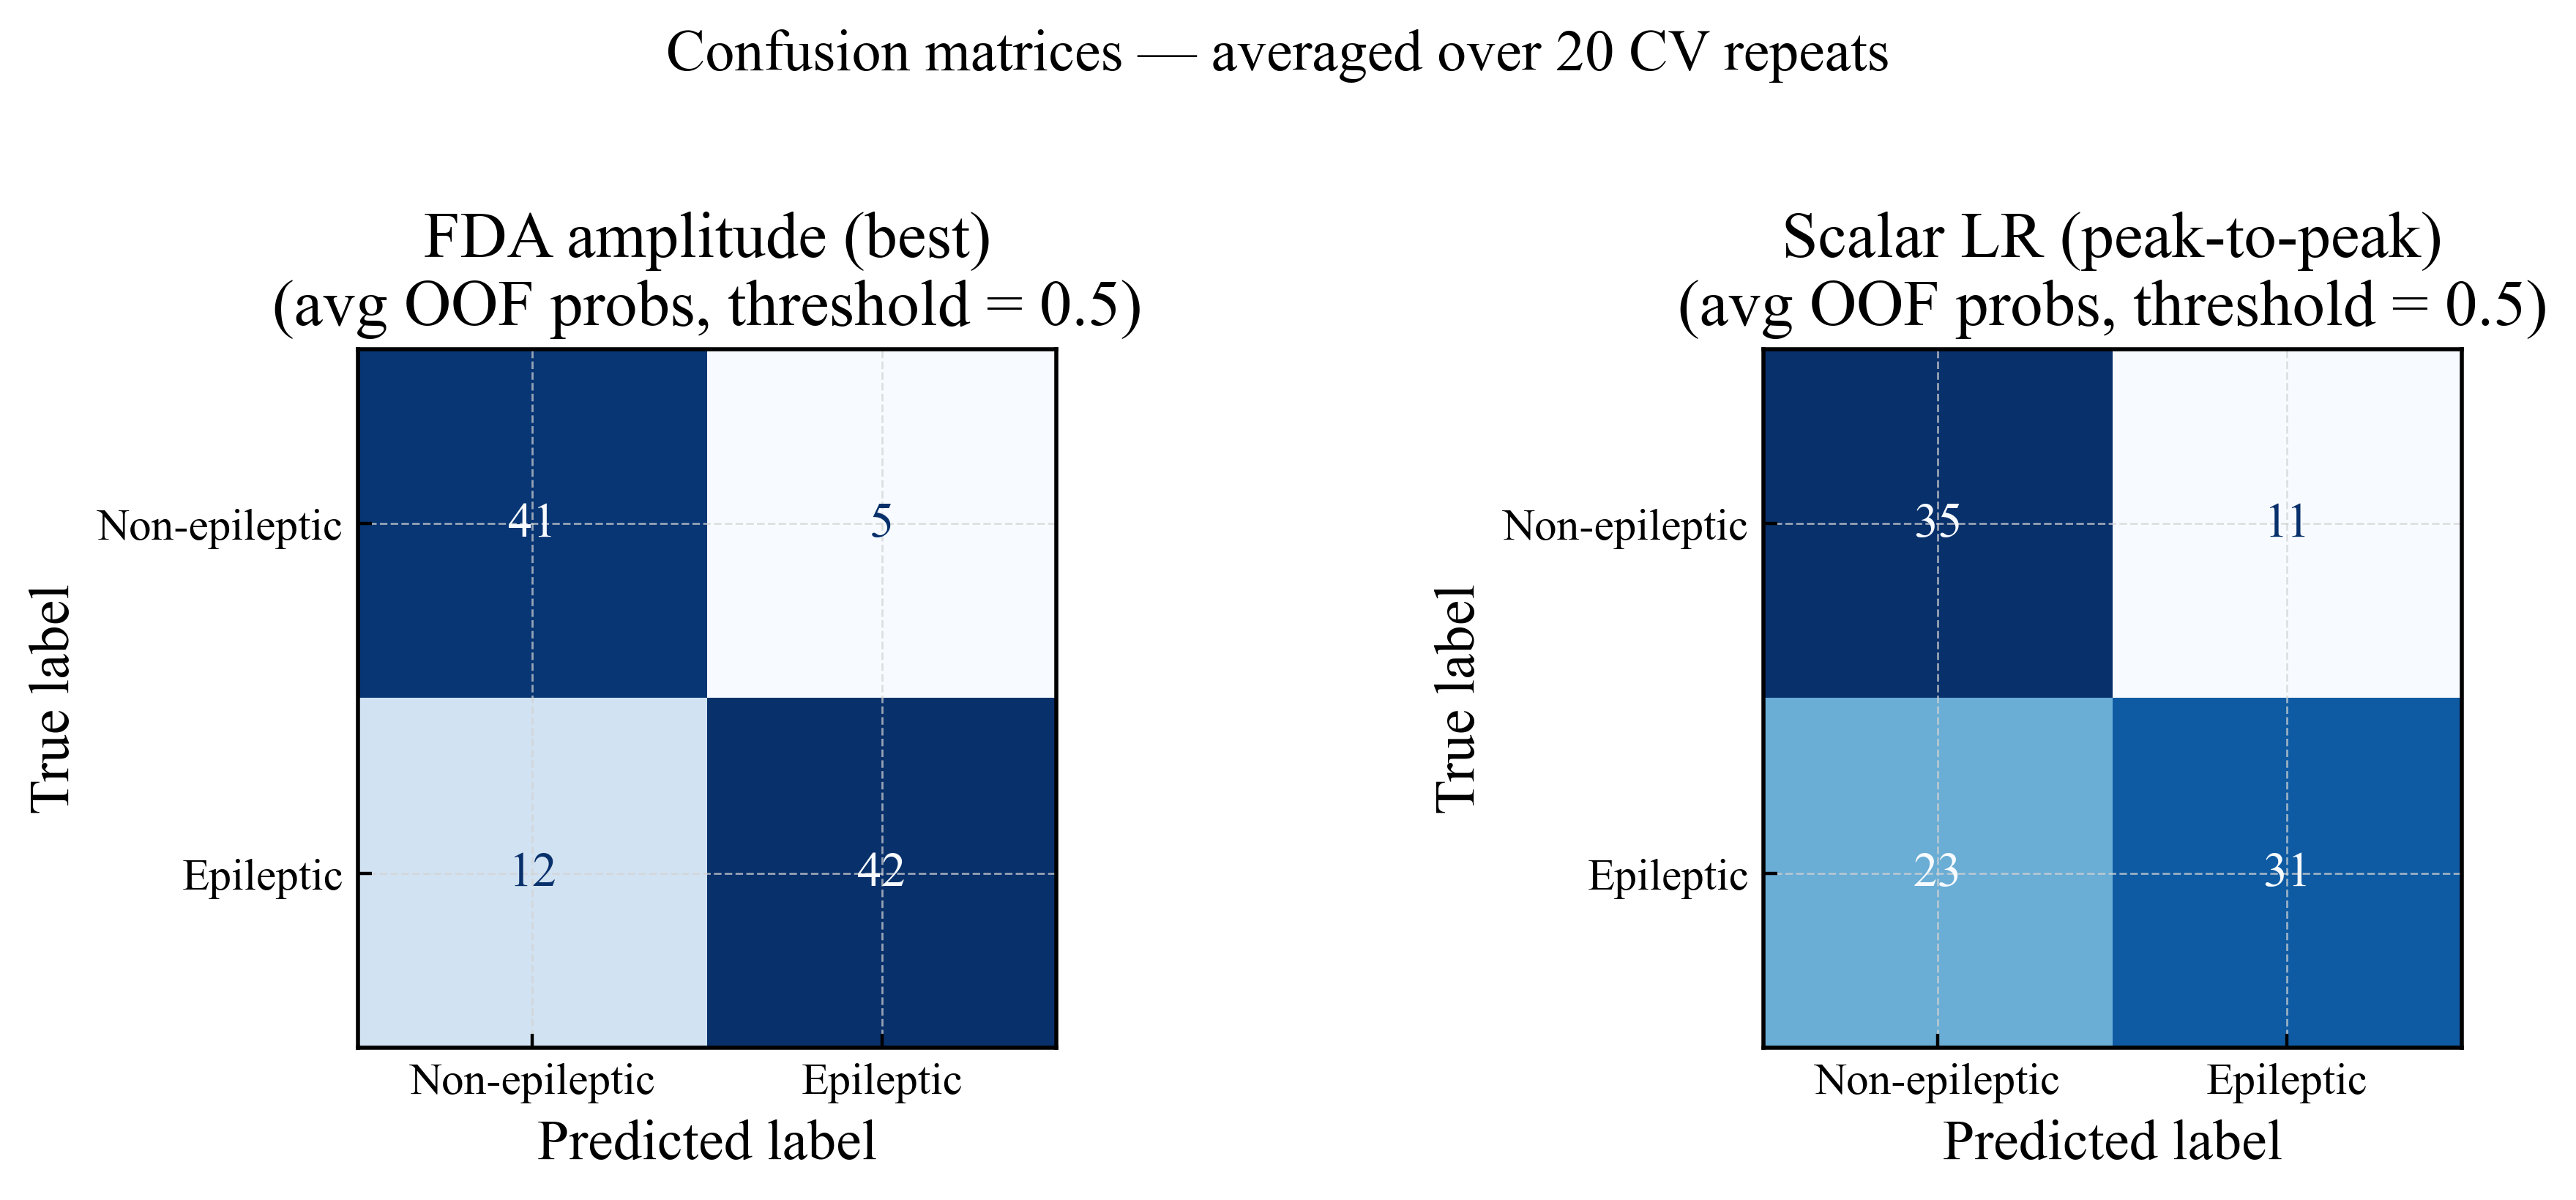

In [ ]:
models_cm = {
    f'FDA {best_cond} (best)':    avg_probs[best_cond],
    'Scalar LR (peak-to-peak)': avg_probs['scalar'],
}

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (title, probs) in zip(axes, models_cm.items()):
    y_pred = (probs >= 0.5).astype(int)
    cm = confusion_matrix(y, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Non-epileptic', 'Epileptic'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title}\n(avg OOF probs, threshold = 0.5)')

plt.suptitle('Confusion matrices — averaged over 20 CV repeats', y=1.02)
plt.tight_layout()
plt.show()

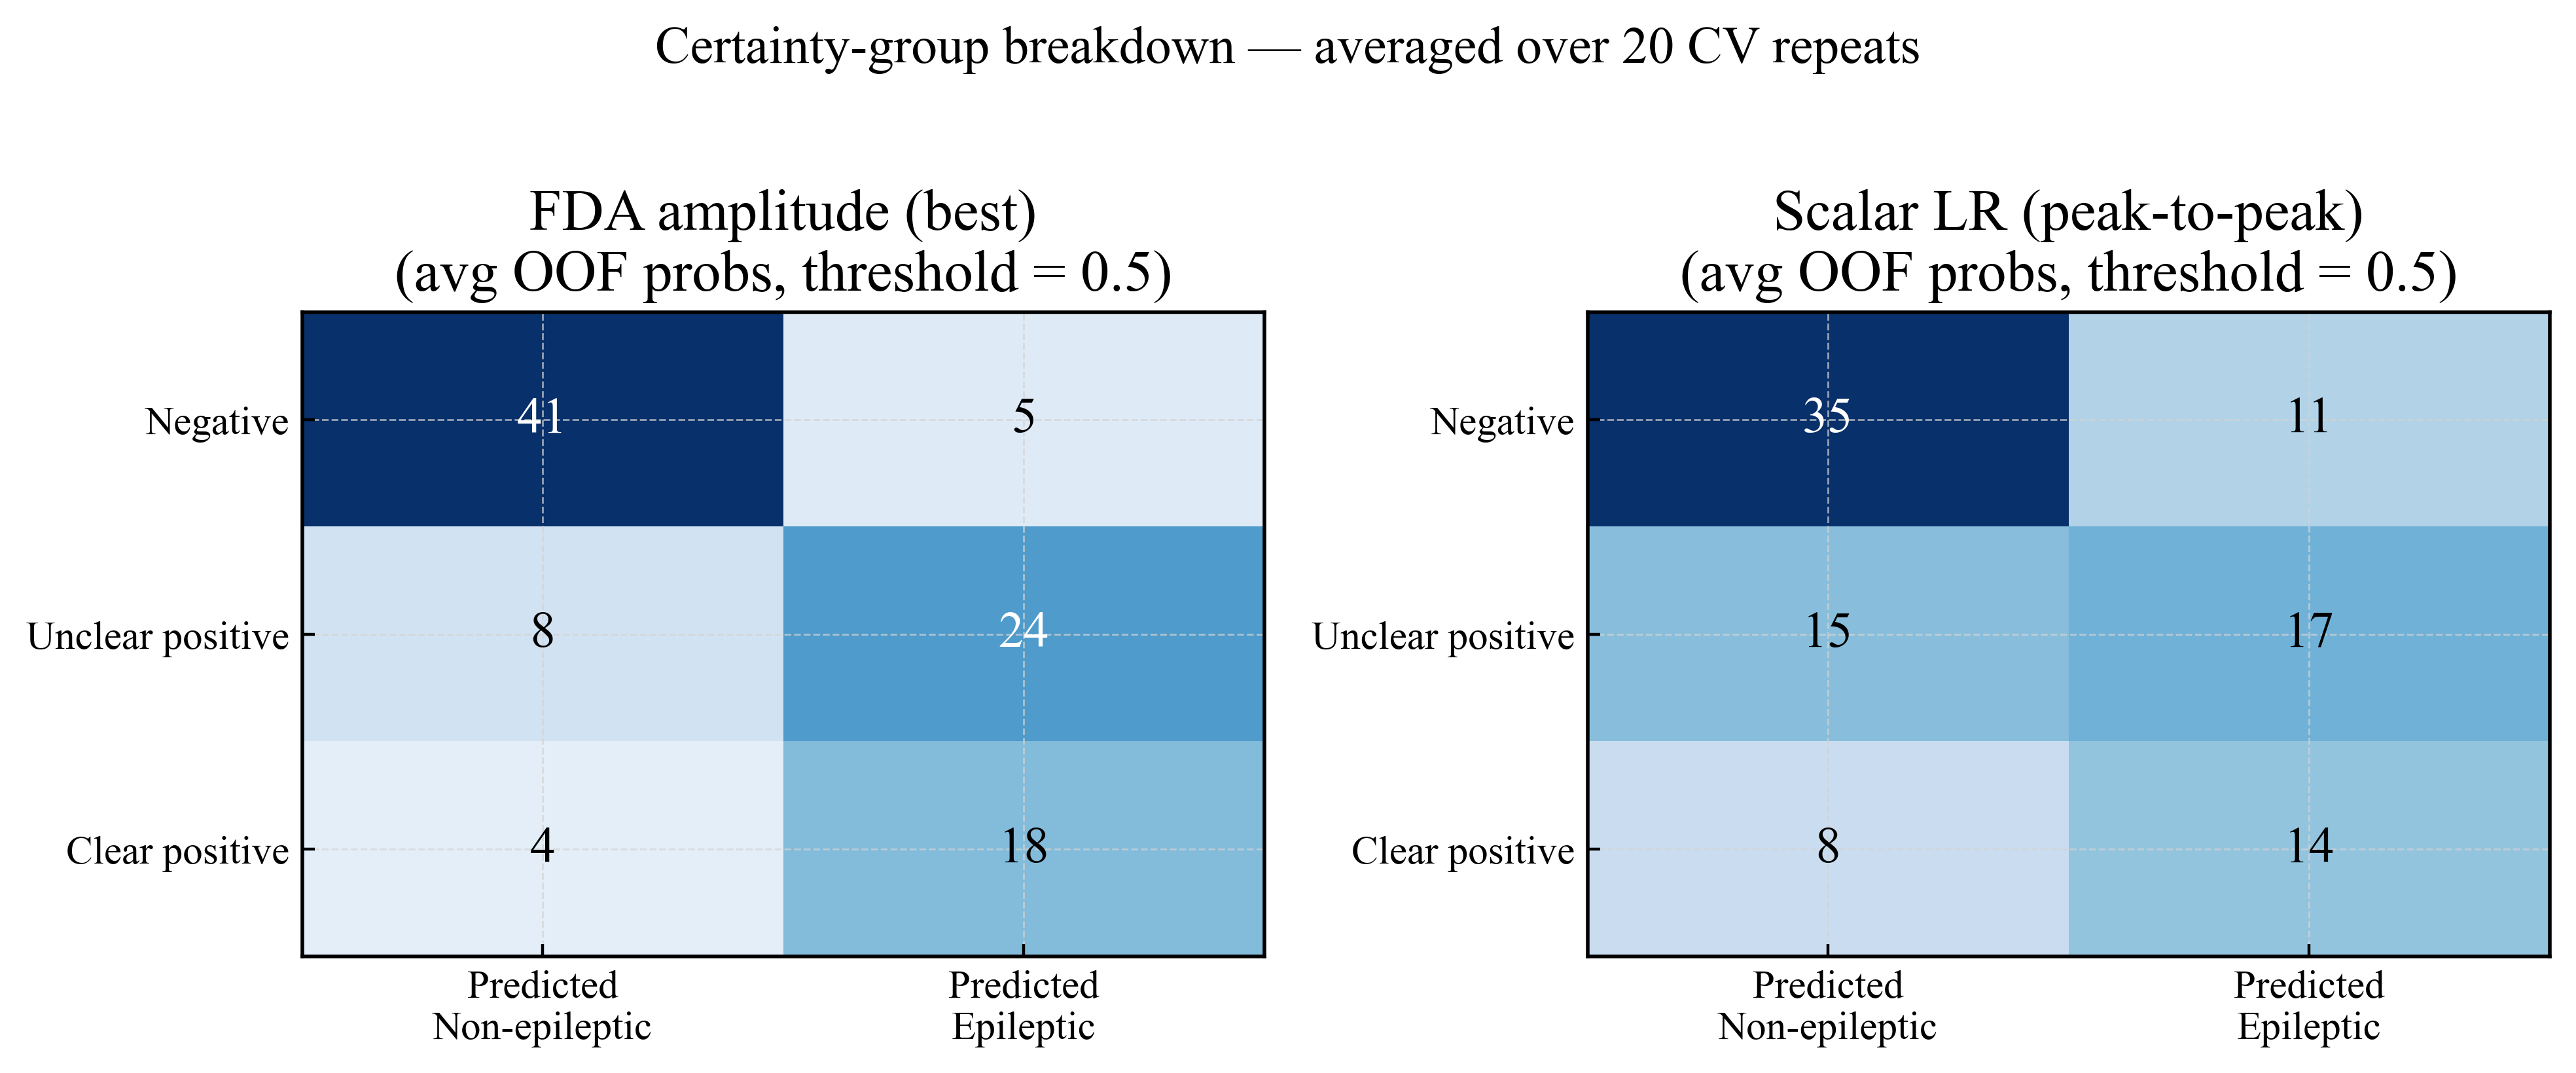

In [20]:
group_order  = ['negative', 'unclear_positive', 'clear_positive']
group_labels = ['Negative', 'Unclear positive', 'Clear positive']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (title, probs) in zip(axes, models_cm.items()):
    y_pred = (probs >= 0.5).astype(int)
    cm = np.array([
        [np.sum((cert == g) & (y_pred == 0)), np.sum((cert == g) & (y_pred == 1))]
        for g in group_order
    ])
    im = ax.imshow(cm, cmap='Blues', aspect='auto', vmin=0)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Predicted\nNon-epileptic', 'Predicted\nEpileptic'])
    ax.set_yticks(range(3))
    ax.set_yticklabels(group_labels)
    ax.set_title(f'{title}\n(avg OOF probs, threshold = 0.5)')
    thresh = cm.max() / 2
    for i in range(3):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=14,
                    color='white' if cm[i, j] > thresh else 'black')

plt.suptitle('Certainty-group breakdown — averaged over 20 CV repeats', y=1.02)
plt.tight_layout()
plt.show()